In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
df = pd.read_csv("titanic.csv")
df.shape

(418, 12)

In [17]:
df = df.drop(columns=["PassengerId","Name","Ticket","Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Sex"] = df["Sex"].map({"male":0,"female":1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,34.5,0,0,7.8292,True,False
1,1,3,1,47.0,1,0,7.0000,False,True
2,0,2,0,62.0,0,0,9.6875,True,False
3,0,3,0,27.0,0,0,8.6625,False,True
4,1,3,1,22.0,1,1,12.2875,False,True


In [18]:
q1,q3 = df["Fare"].quantile([0.25,0.75])
iqr = q3 - q1
df["Fare"] = df["Fare"].clip(lower=q1-1.5*iqr, upper=q3+1.5*iqr)


In [19]:
num_coils = ["Age","Fare"]
scaler = StandardScaler()
df[num_coils] = scaler.fit_transform(df[num_coils])


In [20]:
print("Clean shape:", df.shape)

Clean shape: (418, 9)


In [21]:
print("Missing :", df.isnull().sum().sum())

Missing : 1


In [22]:
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())
print("Missing after dropna:", df.isnull().sum().sum())

Missing after dropna: 0


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    418 non-null    int64  
 1   Pclass      418 non-null    int64  
 2   Sex         418 non-null    int64  
 3   Age         418 non-null    float64
 4   SibSp       418 non-null    int64  
 5   Parch       418 non-null    int64  
 6   Fare        418 non-null    float64
 7   Embarked_Q  418 non-null    bool   
 8   Embarked_S  418 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 23.8 KB


In [24]:
df.dtypes

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object

In [25]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,0.334993,0,0,-0.794535,True,False
1,1,3,1,1.325530,1,0,-0.833638,False,True
2,0,2,0,2.514175,0,0,-0.706902,True,False
3,0,3,0,-0.259330,0,0,-0.755238,False,True
4,1,3,1,-0.655545,1,1,-0.584292,False,True


# EDA

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("titanic.csv")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


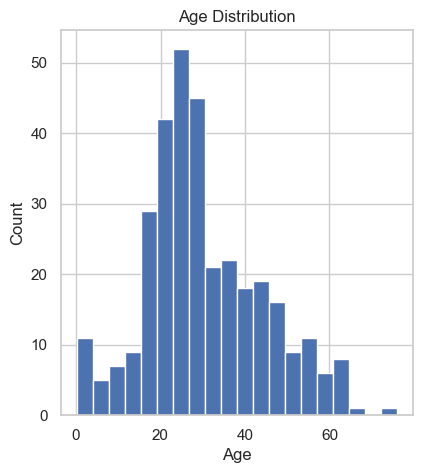

In [28]:
#Histogram
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
df["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


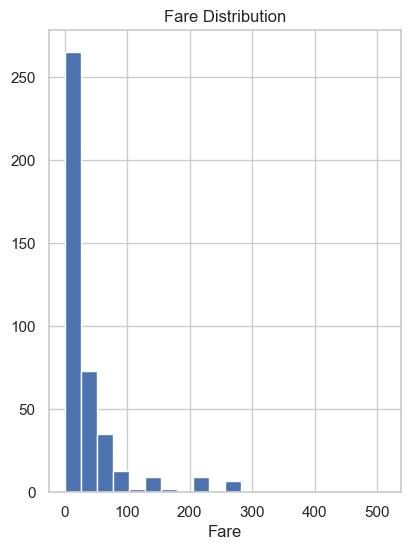

In [29]:
plt.subplot(1,2,2)
df["Fare"].hist(bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.show()
